# 03 Evaluation, Prediction & Explainability (Combined)

Evaluate the saved pass/fail classifier on the combined dataset, generate predictions with risk levels, and extract feature importance for explainability.


In [1]:
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from joblib import load

# Ensure project root is on path for src imports
base_dir = Path("../..").resolve()
sys.path.append(str(base_dir))

sns.set_theme(style="ticks")
processed_dir = base_dir / "data" / "processed" / "performance"
models_dir = base_dir / "models" / "performance"
model_path = models_dir / "pass_classifier_rf.joblib"

# Load data and model
combined_path = processed_dir / "student_all_cleaned.csv"
mat_path = processed_dir / "student_mat_cleaned.csv"
por_path = processed_dir / "student_por_cleaned.csv"

if combined_path.exists():
    full_df = pd.read_csv(combined_path)
else:
    mat_df = pd.read_csv(mat_path).assign(dataset="math")
    por_df = pd.read_csv(por_path).assign(dataset="portuguese")
    full_df = pd.concat([mat_df, por_df], ignore_index=True)
    full_df.to_csv(combined_path, index=False)

model = load(model_path)
print(f"Loaded model from {model_path}")
print(full_df.shape)


Loaded model from /Users/admin/Documents/GitHub/testITprojc/models/performance/pass_classifier_rf.joblib
(1044, 34)


In [2]:
# Split features/target and hold-out test set
X = full_df.drop(columns=["G3", "pass"])
y = full_df["pass"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [3]:
# Evaluate classification metrics
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.77      0.72      0.74        46
           1       0.92      0.94      0.93       163

    accuracy                           0.89       209
   macro avg       0.84      0.83      0.84       209
weighted avg       0.89      0.89      0.89       209

Confusion matrix:
 [[ 33  13]
 [ 10 153]]
ROC AUC: 0.9514537209922646


In [4]:
# Threshold sweep to boost fail recall (lower threshold => more predicted fails)
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

thresholds = np.arange(0.3, 0.65, 0.05)
rows = []
for thr in thresholds:
    y_pred_thr = (y_prob >= thr).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_thr, average=None, labels=[0,1])
    rows.append({
        "threshold": round(thr, 3),
        "fail_recall": round(recall[0], 3),
        "fail_precision": round(precision[0], 3),
        "pass_recall": round(recall[1], 3),
        "pass_precision": round(precision[1], 3),
    })

sweep_df = pd.DataFrame(rows)
sweep_df

,threshold,fail_recall,fail_precision,pass_recall,pass_precision
0,0.30,0.326,0.882,0.988,0.839
1,0.35,0.435,0.870,0.982,0.860
2,0.40,0.587,0.844,0.969,0.893
3,0.45,0.696,0.800,0.951,0.917
4,0.50,0.717,0.767,0.939,0.922
5,0.55,0.739,0.773,0.939,0.927
6,0.60,0.761,0.761,0.933,0.933


In [5]:
# Build prediction dataframe with risk levels
from src.predict import risk_level

test_results = X_test.copy().reset_index(drop=True)
test_results["actual_pass"] = y_test.reset_index(drop=True)
test_results["pred_pass"] = y_pred
test_results["risk_score"] = 1.0 - y_prob
test_results["risk_level"] = test_results["risk_score"].apply(risk_level)
test_results.insert(0, "student_id", test_results.index + 1)

# Save predictions
pred_path = processed_dir / "student_predictions_holdout.csv"
test_results.to_csv(pred_path, index=False)
print(f"Saved holdout predictions with risk levels to {pred_path}")

test_results.head()

Saved predictions with risk levels to /Users/admin/Documents/GitHub/testITprojc/data/processed/performance/student_predictions.csv


,student_id,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,...,Dalc,Walc,health,absences,G1,G2,actual_pass,pred_pass,risk_score,risk_level
0,1,GP,F,18,U,GT3,T,2,3,at_home,...,1,2,3,4,11,10,1,1,0.9700,High
1,2,GP,F,17,U,GT3,T,3,2,other,...,1,3,3,10,16,15,1,1,0.9950,High
2,3,MS,M,17,U,GT3,T,2,3,other,...,1,1,3,4,14,15,1,1,0.9950,High
3,4,MS,F,16,U,LE3,T,1,1,at_home,...,1,3,5,6,6,8,0,0,0.3100,Medium
4,5,GP,F,17,R,GT3,A,3,2,other,...,2,3,2,4,9,10,1,1,0.8125,High


In [6]:
# Feature importance (RandomForest)
rf_model = model.named_steps.get("model", None)
preprocess = model.named_steps.get("preprocess", None)

if preprocess is not None:
    feature_names = preprocess.get_feature_names_out()
else:
    feature_names = X.columns

importances = rf_model.feature_importances_
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values(by="importance", ascending=False)

importance_df.head(15)


,feature,importance
57,num__G2,0.338172
56,num__G1,0.221811
48,num__failures,0.050668
55,num__absences,0.031108
51,num__goout,0.016761
43,num__age,0.016319
50,num__freetime,0.014222
45,num__Fedu,0.014165
53,num__Walc,0.013979
44,num__Medu,0.013626


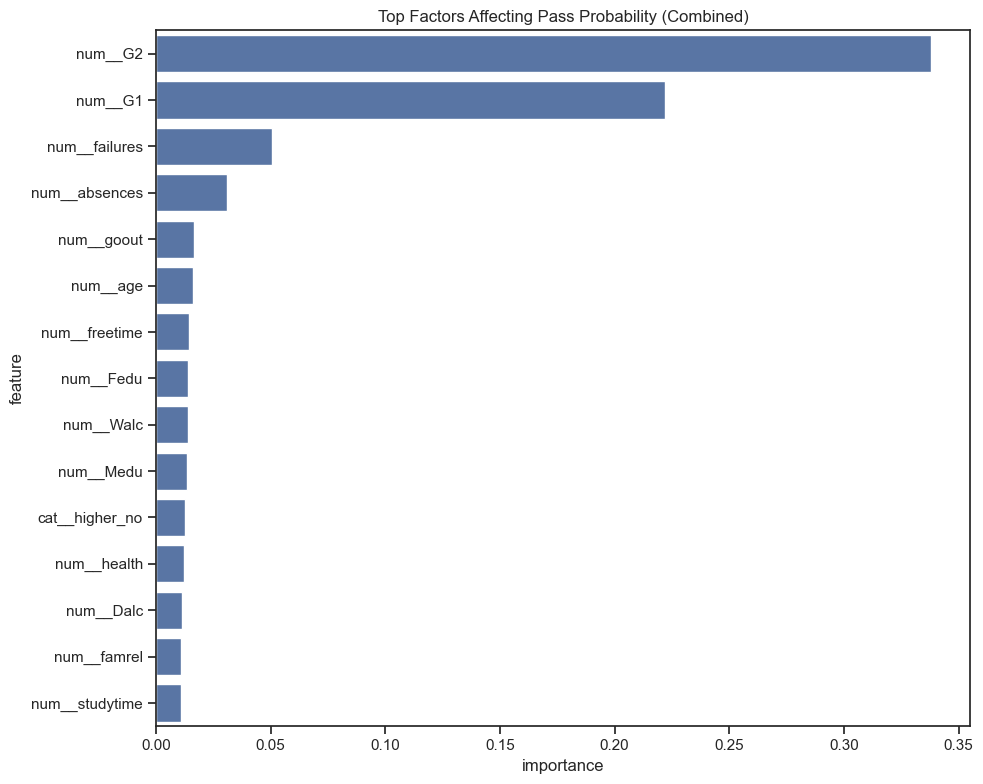

In [7]:
# Plot top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(x="importance", y="feature", data=importance_df.head(15))
plt.title("Top Factors Affecting Pass Probability (Combined)")
plt.tight_layout()
plt.show()


### Next steps
- Add SHAP for per-student explanations (install `shap` and use `TreeExplainer`).
- Sweep decision thresholds to prioritize recall if needed.
- Generate predictions for new cohorts and feed to downstream dashboard.
